In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import galsim
import numpy as np
import anacal
import os
import matplotlib.pyplot as plt
import fitsio

In [2]:
def simulate_exp_gal_stamp(
    hlr_arcsec: float,
    g1: float = 0.02,
    g2: float = 0.0,
    rot_angle_deg: float = 0.0,     
    axis_ratio: float = 0.4,
    stamp_size: int = 64,
    pixel_scale: float = 0.2,
    psf_beta: float = 2.0,
    psf_fwhm_arcsec: float = 0.8,
    gal_flux: float = 200.0,
):
    if not (0.0 < axis_ratio <= 1.0):
        raise ValueError(f"axis_ratio must be in (0, 1], got {axis_ratio}")

    beta = np.deg2rad(rot_angle_deg)
    e = (1.0 - axis_ratio) / (1.0 + axis_ratio)
    e1 = e * np.cos(2.0 * beta)
    e2 = e * np.sin(2.0 * beta)

    gal = galsim.Exponential(half_light_radius=hlr_arcsec, flux=gal_flux)

    # intrinsic ellipticity first
    if e != 0.0:
        gal = gal.shear(e1=e1, e2=e2)

    # then lensing shear
    if (g1 != 0.0) or (g2 != 0.0):
        gal = gal.shear(g1=g1, g2=g2)

    # --- PSF ---
    psf = galsim.Moffat(beta=psf_beta, fwhm=psf_fwhm_arcsec)

    final = galsim.Convolve([gal, psf])

    gal_img = galsim.ImageF(stamp_size, stamp_size, scale=pixel_scale)
    psf_img = galsim.ImageF(stamp_size, stamp_size, scale=pixel_scale)
    gal_img.setOrigin(0, 0)
    psf_img.setOrigin(0, 0)

    half_pixel_offset = galsim.PositionD(0.5, 0.5)
    final.drawImage(image=gal_img, method="fft", offset=half_pixel_offset)
    psf.drawImage(image=psf_img, method="fft", offset=half_pixel_offset)

    return gal_img, psf_img

def measure(
    gal_array: np.ndarray,
    psf_array: np.ndarray,
    pixel_scale: float,
    noise_variance: float = 0.25,
    noise_array: np.ndarray | None = None,
    g1_input: float = 0.02,
):
    npix = gal_array.shape[0]
    assert gal_array.shape == (npix, npix)
    assert psf_array.shape == (npix, npix)

    dtype = np.dtype([("y", np.int32), ("x", np.int32)])
    detection = np.empty(1, dtype=dtype)
    detection["y"] = npix // 2
    detection["x"] = npix // 2

    # FPFS config (same as your example)
    fpfs_config = anacal.fpfs.FpfsConfig(
        sigma_shapelets1=0.50,
    )

    catalog = anacal.fpfs.process_image(
        fpfs_config=fpfs_config,
        mag_zero=30.0,
        gal_array=gal_array,
        psf_array=psf_array,
        pixel_scale=pixel_scale,
        noise_variance=0.23, # fix a positive variance for selection, though the image is noiseless
        noise_array=noise_array,
        detection=detection,
        return_only_linear_modes=True,
        pack_linear_modes=True,
    )
    return catalog


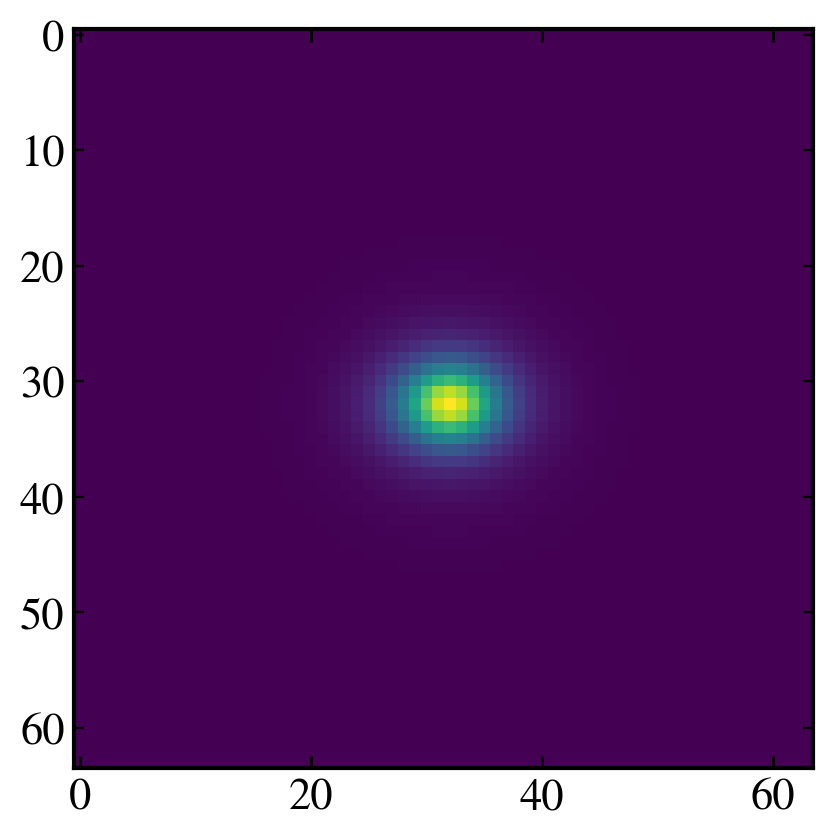

In [3]:
noise_variance = 0.23
pixel_scale = 0.2
g1_input = 0.02
hlr = 0.4
gal_img, psf_img = simulate_exp_gal_stamp(hlr_arcsec=hlr, pixel_scale=pixel_scale, axis_ratio=0.3, rot_angle_deg=0.0, g1=0.0, g2=0.0)
catalog = measure(
    gal_array=gal_img.array,
    psf_array=psf_img.array,
    pixel_scale=pixel_scale,
    noise_variance=noise_variance,
    noise_array=None,
    g1_input=g1_input,
)

plt.imshow(gal_img.array)

In [4]:
def _rot_cs(c, s, phi_rad):
    # Do rotation
    cp = np.cos(phi_rad)
    sp = np.sin(phi_rad)
    return c * cp - s * sp, c * sp + s * cp


def transform_linear_modes(x, theta_deg, g1, g2):
    th = np.deg2rad(theta_deg)
    m00 = np.asarray(x["fpfs1_m00"])
    m20 = np.asarray(x["fpfs1_m20"])
    m40 = np.asarray(x["fpfs1_m40"])
    m22c, m22s = _rot_cs(np.asarray(x["fpfs1_m22c"]), np.asarray(x["fpfs1_m22s"]), 2.0 * th)
    m42c, m42s = _rot_cs(np.asarray(x["fpfs1_m42c"]), np.asarray(x["fpfs1_m42s"]), 2.0 * th)
    m44c, m44s = _rot_cs(np.asarray(x["fpfs1_m44c"]), np.asarray(x["fpfs1_m44s"]), 4.0 * th)
    
    n00 = np.asarray(x["fpfs1_n00"])
    n20 = np.asarray(x["fpfs1_n20"])
    n40 = np.asarray(x["fpfs1_n40"])
    n22c, n22s = _rot_cs(np.asarray(x["fpfs1_n22c"]), np.asarray(x["fpfs1_n22s"]), 2.0 * th)
    n42c, n42s = _rot_cs(np.asarray(x["fpfs1_n42c"]), np.asarray(x["fpfs1_n42s"]), 2.0 * th)
    n44c, n44s = _rot_cs(np.asarray(x["fpfs1_n44c"]), np.asarray(x["fpfs1_n44s"]), 4.0 * th)
    
    # noise biase correction for
    # moments used to calculate shear response of nonlinear function of the modes 
    # 
    m00_r = m00 - 2.0 * n00
    m20_r = m20 - 2.0 * n20
    m40_r = m40 - 2.0 * n40
    m22c_r = m22c - 2.0 * n22c
    m22s_r = m22s - 2.0 * n22s
    m42c_r = m42c - 2.0 * n42c
    m42s_r = m42s - 2.0 * n42s
    m44c_r = m44c - 2.0 * n44c
    m44s_r = m44s - 2.0 * n44s

    rt2 = np.sqrt(2.0)
    rt3 = np.sqrt(3.0)
    rt6 = np.sqrt(6.0)

    dm00_dg1 = -rt2 * m22c_r
    dm00_dg2 = -rt2 * m22s_r

    dm20_dg1 = -rt6 * m42c_r
    dm20_dg2 = -rt6 * m42s_r

    dm22c_dg1 = (1.0 / rt2) * (m00_r - m40_r) - rt3 * m44c_r
    dm22c_dg2 = -rt3 * m44s_r

    dm22s_dg1 = -rt3 * m44s_r
    dm22s_dg2 = (1.0 / rt2) * (m00_r - m40_r) + rt3 * m44c_r

    m00_p  = m00  + g1 * dm00_dg1  + g2 * dm00_dg2
    m20_p  = m20  + g1 * dm20_dg1  + g2 * dm20_dg2
    m22c_p = m22c + g1 * dm22c_dg1 + g2 * dm22c_dg2
    m22s_p = m22s + g1 * dm22s_dg1 + g2 * dm22s_dg2

    # --- pack output (same length as input) ---
    out = np.empty(len(m00_p), dtype=[
        ("fpfs1_m00",  "f8"),
        ("fpfs1_m20",  "f8"),
        ("fpfs1_m22c", "f8"),
        ("fpfs1_m22s", "f8"),
    ])
    out["fpfs1_m00"]  = m00_p
    out["fpfs1_m20"]  = m20_p
    out["fpfs1_m22c"] = m22c_p
    out["fpfs1_m22s"] = m22s_p
    return out

In [5]:
theta = 30.0
g1 = 0.02
g2 = -0.015
gal_img, psf_img = simulate_exp_gal_stamp(hlr_arcsec=hlr, pixel_scale=pixel_scale, axis_ratio=0.3, rot_angle_deg=theta, g1=g1, g2=g2)
catalog2 = measure(
    gal_array=gal_img.array,
    psf_array=psf_img.array,
    pixel_scale=pixel_scale,
    noise_variance=noise_variance,
    noise_array=None,
    g1_input=g1_input,
)

In [6]:
transform_linear_modes(catalog, theta_deg=theta, g1=g1, g2=g2)

array([(79.88254661, -29.87343563, 7.10061051, 10.02321291)],
      dtype=[('fpfs1_m00', '<f8'), ('fpfs1_m20', '<f8'), ('fpfs1_m22c', '<f8'), ('fpfs1_m22s', '<f8')])

In [7]:
catalog2[["fpfs1_m00", "fpfs1_m20", "fpfs1_m22c", "fpfs1_m22s"]]

array([(79.86233164, -29.85657659, 7.09571729, 10.01393721)],
      dtype={'names': ['fpfs1_m00', 'fpfs1_m20', 'fpfs1_m22c', 'fpfs1_m22s'], 'formats': ['<f8', '<f8', '<f8', '<f8'], 'offsets': [0, 8, 16, 24], 'itemsize': 200})

In [8]:
catalog[["fpfs1_m00", "fpfs1_m20", "fpfs1_m22c", "fpfs1_m22s"]]

array([(79.83035696, -29.82988689, 12.34078633, 4.38148484e-15)],
      dtype={'names': ['fpfs1_m00', 'fpfs1_m20', 'fpfs1_m22c', 'fpfs1_m22s'], 'formats': ['<f8', '<f8', '<f8', '<f8'], 'offsets': [0, 8, 16, 24], 'itemsize': 200})

In [9]:
def transform_ellipticity(x, C, theta_deg, g1, g2):
    th = np.deg2rad(theta_deg)
    m00 = np.asarray(x["fpfs1_m00"])
    m20 = np.asarray(x["fpfs1_m20"])
    m40 = np.asarray(x["fpfs1_m40"])
    m22c, m22s = _rot_cs(np.asarray(x["fpfs1_m22c"]), np.asarray(x["fpfs1_m22s"]), 2.0 * th)
    m42c, m42s = _rot_cs(np.asarray(x["fpfs1_m42c"]), np.asarray(x["fpfs1_m42s"]), 2.0 * th)
    m44c, m44s = _rot_cs(np.asarray(x["fpfs1_m44c"]), np.asarray(x["fpfs1_m44s"]), 4.0 * th)
    
    n00 = np.asarray(x["fpfs1_n00"])
    n20 = np.asarray(x["fpfs1_n20"])
    n40 = np.asarray(x["fpfs1_n40"])
    n22c, n22s = _rot_cs(np.asarray(x["fpfs1_n22c"]), np.asarray(x["fpfs1_n22s"]), 2.0 * th)
    n42c, n42s = _rot_cs(np.asarray(x["fpfs1_n42c"]), np.asarray(x["fpfs1_n42s"]), 2.0 * th)
    n44c, n44s = _rot_cs(np.asarray(x["fpfs1_n44c"]), np.asarray(x["fpfs1_n44s"]), 4.0 * th)
    
    # noise biase correction for
    # moments used to calculate shear response of nonlinear function of the modes 
    # 
    m00_r = m00 - 2.0 * n00
    m20_r = m20 - 2.0 * n20
    m40_r = m40 - 2.0 * n40
    m22c_r = m22c - 2.0 * n22c
    m22s_r = m22s - 2.0 * n22s
    m42c_r = m42c - 2.0 * n42c
    m42s_r = m42s - 2.0 * n42s
    m44c_r = m44c - 2.0 * n44c
    m44s_r = m44s - 2.0 * n44s

    rt2 = np.sqrt(2.0)
    rt3 = np.sqrt(3.0)
    rt6 = np.sqrt(6.0)

    e44c_r = m44c_r / (m00_r + C)
    e44s_r = m44s_r / (m00_r + C)
    
    e22c_r = m22c_r / (m00_r + C)
    e22s_r = m22s_r / (m00_r + C)
    R_r = 1.0 / rt2 * (m00_r - m40_r) / (m00_r + C)
    
    de1_dg1 = R_r - rt3 * e44c_r + rt2 * e22c_r * e22c_r
    de2_dg2 = R_r + rt3 * e44c_r + rt2 * e22s_r * e22s_r
    de1_dg2 = -rt3 * e44s_r + rt2 * e22c_r * e22s_r
    de2_dg1 = -rt3 * e44s_r + rt2 * e22c_r * e22s_r
    

    e1_p  = m22c / (m00 + C)  + g1 * de1_dg1  + g2 * de1_dg2
    e2_p  = m22s / (m00 + C)  + g1 * de2_dg1  + g2 * de2_dg2

    # --- pack output (same length as input) ---
    out = np.empty(len(e1_p), dtype=[
        ("fpfs1_e1",  "f8"),
        ("fpfs1_e2",  "f8"),
    ])
    out["fpfs1_e1"]  = e1_p
    out["fpfs1_e2"]  = e2_p
    return out

In [10]:
C = 5.0
transform_ellipticity(catalog, C=C, theta_deg=theta, g1=g1, g2=g2)

array([(0.0836589, 0.11807846)],
      dtype=[('fpfs1_e1', '<f8'), ('fpfs1_e2', '<f8')])

In [11]:
print(catalog2["fpfs1_m22c"] / (catalog2["fpfs1_m00"] + C), catalog2["fpfs1_m22s"] / (catalog2["fpfs1_m00"] + C))

[0.08361445] [0.11800215]


In [12]:
print(catalog["fpfs1_m22c"] / (catalog["fpfs1_m00"] + C), catalog["fpfs1_m22s"] / (catalog["fpfs1_m00"] + C))

[0.14547606] [5.16499634e-17]
